In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import torch.optim as optim


torch.manual_seed(42)
np.random.seed(140)

In [71]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [124]:
df = pd.read_csv('inital.csv')
y = df['y']
x1 = df['x1']
x2 = df['x2']
o = y == 0
plus = y == 1

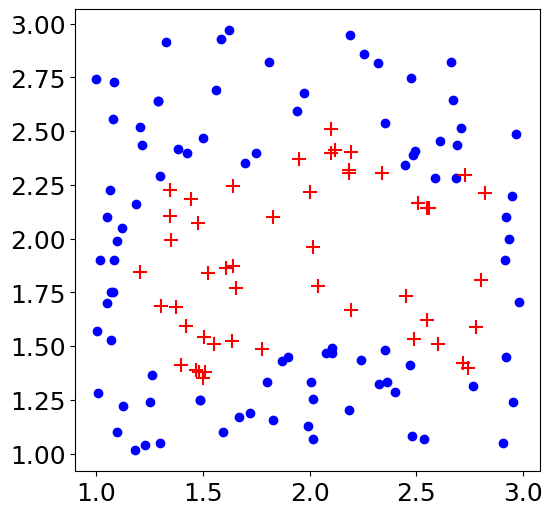

In [129]:


plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(figsize=(6,6))
plt.scatter(x1[o], x2[o], marker='o', color='blue', label='y=0')
plt.scatter(x1[plus], x2[plus], marker='+', color='red', s=100, label='y=1')
# plt.xlabel('x1')
# plt.ylabel('x2')
# # plt.title('Decision Boundary')
# plt.tight_layout()
plt.savefig("data_dist.pdf", format='pdf')

In [134]:
x_lims = ax.get_xlim()

In [135]:
x_lims

(0.9029601334007787, 3.081167360786655)

A simple decision tree, non-differntiable

Feature importances: x1 = 0.4258, x2 = 0.5742


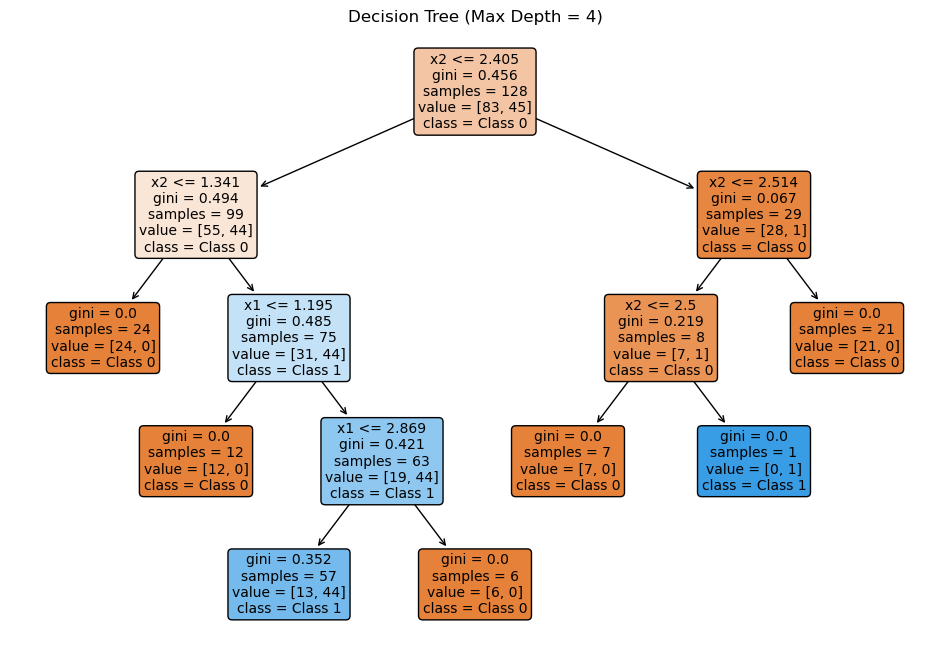

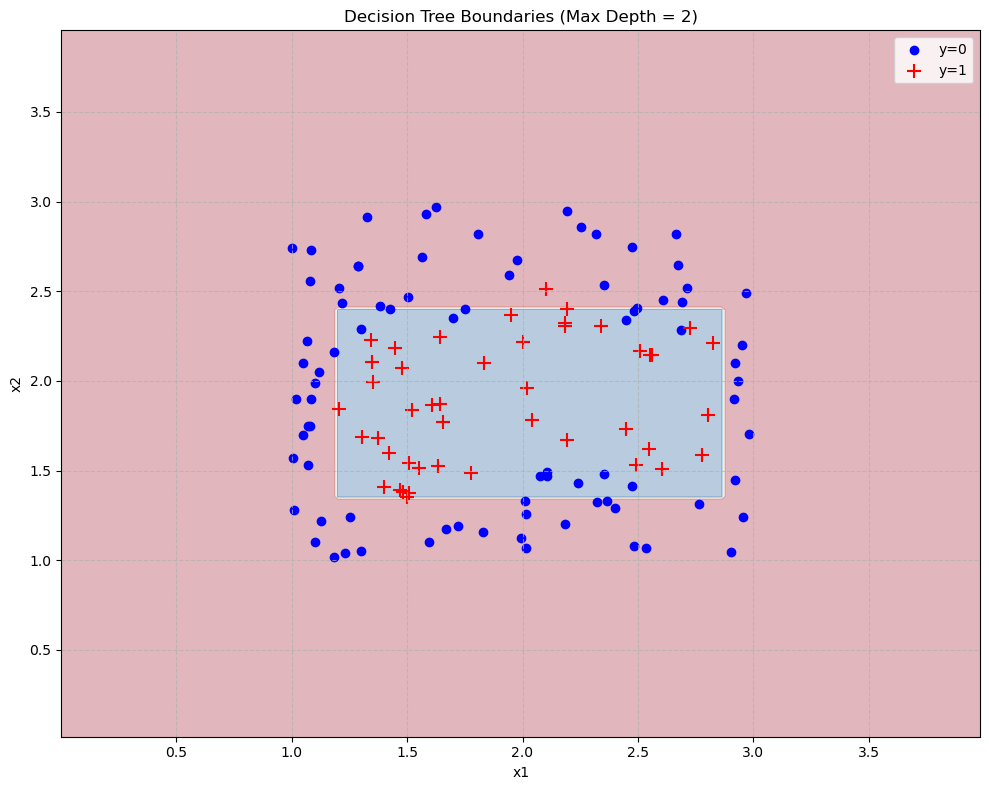

In [4]:
X = np.column_stack((x1, x2))

# Create a decision tree classifier with max depth of 2
clf = DecisionTreeClassifier(max_depth=4, random_state=42)

# Train the classifier
clf.fit(X, y)

# Create a figure
plt.figure(figsize=(12, 8))

# Plot the decision tree
plot_tree(clf, 
          feature_names=['x1', 'x2'],
          class_names=['Class 0', 'Class 1'],
          filled=True,
          rounded=True,
          fontsize=10)

plt.title('Decision Tree (Max Depth = 4)')

# Let's also visualize the decision boundaries in the feature space
plt.figure(figsize=(10, 8))

# Create a meshgrid to plot the decision boundaries
h = 0.02  # Step size
x1_min, x1_max = x1.min() - 1, x1.max() + 1
x2_min, x2_max = x2.min() - 1, x2.max() + 1
xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, h),
                       np.arange(x2_min, x2_max, h))

# Make predictions on the meshgrid
Z = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
Z = Z.reshape(xx1.shape)

# Plot the decision boundaries
plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=plt.cm.RdBu)

# Plot the original data points
zeros = y == 0
ones = y == 1
plt.scatter(x1[zeros], x2[zeros], marker='o', color='blue', label='y=0')
plt.scatter(x1[ones], x2[ones], marker='+', color='red', s=100, label='y=1')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Decision Tree Boundaries (Max Depth = 2)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Show feature importances
importances = clf.feature_importances_
print(f"Feature importances: x1 = {importances[0]:.4f}, x2 = {importances[1]:.4f}")





plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

NameError: name 'X' is not defined

In [11]:

class SimpleNN(nn.Module):
    def __init__(self, input_size):
        super(SimpleNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 3, bias=True),
            # nn.BatchNorm1d(4),
            # nn.Dropout(0.25),
            nn.ReLU(),
            nn.Linear(3, 1, bias=True),
            #nn.Dropout(0.5),
            # nn.ReLU(),
            # nn.Linear(1, 1),
            # Sigmoid activation for binary classification (outputs between 0 and 1)
            nn.Sigmoid()
        )
    def forward(self, x):
        
        return self.model(x)


def prepare_data(df, x_cols=['x1', 'x2'], y_col='y', test_size=0.2):
    
    X = df[x_cols].values
    y = df[y_col].values.reshape(-1, 1)
    

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    

    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train)
    X_test_tensor = torch.FloatTensor(X_test)
    y_test_tensor = torch.FloatTensor(y_test)
    
    return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor, scaler


def train_model(model, X_train, y_train, X_test, y_test, epochs=1000, lr=0.04, batch_size=None):

    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    
    # Lists to store loss history
    train_losses = []
    test_losses = []
    

    for epoch in range(epochs):

        outputs = model(X_train)
        train_loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        

        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test)
            test_losses.append(test_loss.item())
        

        train_losses.append(train_loss.item())

        if (epoch+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')
    
    return train_losses, test_losses


def evaluate_model(model, X_test, y_test):
    with torch.no_grad():

        y_pred = model(X_test)
        

        y_pred_binary = (y_pred > 0.5).float()
        

        accuracy = (y_pred_binary == y_test).float().mean().item()
        
        print(f'Test Accuracy: {accuracy:.4f}')

        true_positives = ((y_pred_binary == 1) & (y_test == 1)).float().sum().item()
        false_positives = ((y_pred_binary == 1) & (y_test == 0)).float().sum().item()
        true_negatives = ((y_pred_binary == 0) & (y_test == 0)).float().sum().item()
        false_negatives = ((y_pred_binary == 0) & (y_test == 1)).float().sum().item()
        
        print("Confusion Matrix:")
        print(f"True Positives: {true_positives}, False Positives: {false_positives}")
        print(f"True Negatives: {true_negatives}, False Negatives: {false_negatives}")
    
    return accuracy


# Plot the loss curves
def plot_losses(train_losses, test_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(test_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



In [15]:
x_columns=['x1', 'x2']
y_column='y'
X_train, X_test, y_train, y_test, scaler = prepare_data(
    df, x_cols=x_columns, y_col=y_column, test_size=0.01
)

# Initialize the model
input_size = len(x_columns)
model = SimpleNN(input_size)

# Train the model
train_losses, test_losses = train_model(
    model, X_train, y_train, X_test, y_test, 
    epochs=4000, lr=0.04
)


# Plot the decision boundary (only if we have 2 features)



Epoch [100/4000], Train Loss: 0.6505, Test Loss: 0.4592
Epoch [200/4000], Train Loss: 0.6465, Test Loss: 0.4455
Epoch [300/4000], Train Loss: 0.6431, Test Loss: 0.4454
Epoch [400/4000], Train Loss: 0.6397, Test Loss: 0.4458
Epoch [500/4000], Train Loss: 0.6354, Test Loss: 0.4431
Epoch [600/4000], Train Loss: 0.6294, Test Loss: 0.4351
Epoch [700/4000], Train Loss: 0.6201, Test Loss: 0.4230
Epoch [800/4000], Train Loss: 0.6091, Test Loss: 0.4048
Epoch [900/4000], Train Loss: 0.5951, Test Loss: 0.3719
Epoch [1000/4000], Train Loss: 0.5767, Test Loss: 0.3281
Epoch [1100/4000], Train Loss: 0.5587, Test Loss: 0.2856
Epoch [1200/4000], Train Loss: 0.5423, Test Loss: 0.2483
Epoch [1300/4000], Train Loss: 0.5288, Test Loss: 0.2174
Epoch [1400/4000], Train Loss: 0.5174, Test Loss: 0.1913
Epoch [1500/4000], Train Loss: 0.5072, Test Loss: 0.1702
Epoch [1600/4000], Train Loss: 0.4973, Test Loss: 0.1527
Epoch [1700/4000], Train Loss: 0.4855, Test Loss: 0.1384
Epoch [1800/4000], Train Loss: 0.4752, T

In [137]:
# Visualize decision boundary
def plot_decision_boundary(model, X, y, scaler, feature_names=['x1', 'x2']):
    # Create a mesh grid to visualize the decision boundary
    x1_min, x1_max = 1.0, 3
    x2_min, x2_max = 1, 3
    h = 0.005
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, h), np.arange(x2_min, x2_max, h))
    
    # Scale mesh grid points
    grid_points = np.c_[xx1.ravel(), xx2.ravel()]
    scaled_grid_points = scaler.transform(grid_points)
    
    # Predict for each point in the mesh grid
    Z = model(torch.FloatTensor(scaled_grid_points))
    Z = Z.detach().numpy().reshape(xx1.shape)
    Z = (Z > 0.5).astype(int)
    # Plot decision boundary and data points
    
    plt.rcParams.update({'font.size': 18})
    plt.figure(figsize=(6, 6))
    # This functions colors the inside of the plot
    # plt.contourf(xx1, xx2, Z, alpha=0.8, cmap=plt.cm.Purples)
    plt.contour(xx1, xx2, Z, levels=[0.5], colors='purple', linewidths=2)
    plt.ylim(0.9174749336465787, 3.066280477258978)
    plt.xlim(0.9029601334007787, 3.081167360786655)
    o = y == 0
    plus = y == 1

    original_data = scaler.inverse_transform(X_train.numpy())

    #plt.scatter(original_data[:, 0], original_data[:, 1], c=y_pred_binary.squeeze(), edgecolors='k', cmap=plt.cm.RdBu)
    plt.scatter(original_data[o.reshape(-1,), 0], original_data[o.reshape(-1,), 1], marker='o', color='blue', label='y=0')

    # Plot points where y=1 as plus signs
    plt.scatter(original_data[plus.reshape(-1,), 0], original_data[plus.reshape(-1,), 1], marker='+', color='red', s=100, label='y=1')
    # # Get original data (unscaled) for plotting
    # original_data = scaler.inverse_transform(X.numpy())
    # plt.scatter(original_data[:, 0], original_data[:, 1], c=y.squeeze(), edgecolors='k', cmap=plt.cm.RdBu)
    
    # plt.xlabel(feature_names[0])
    # plt.ylabel(feature_names[1])
    # # plt.title('Decision Boundary')
    # plt.tight_layout()
    plt.savefig("decisionboundary.pdf", format='pdf')
    plt.show()


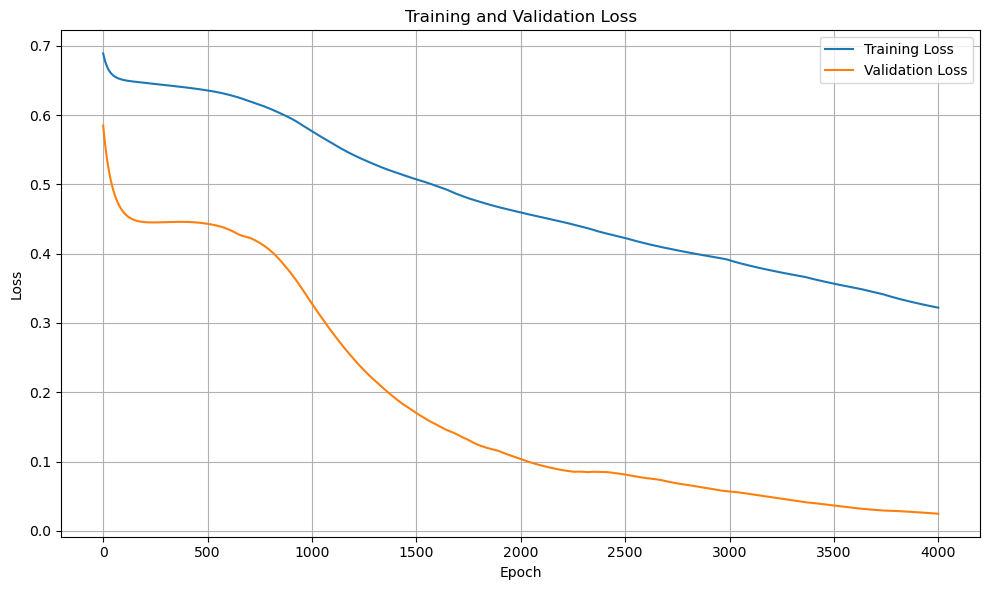

Test Accuracy: 0.8651
Confusion Matrix:
True Positives: 36.0, False Positives: 8.0
True Negatives: 73.0, False Negatives: 9.0


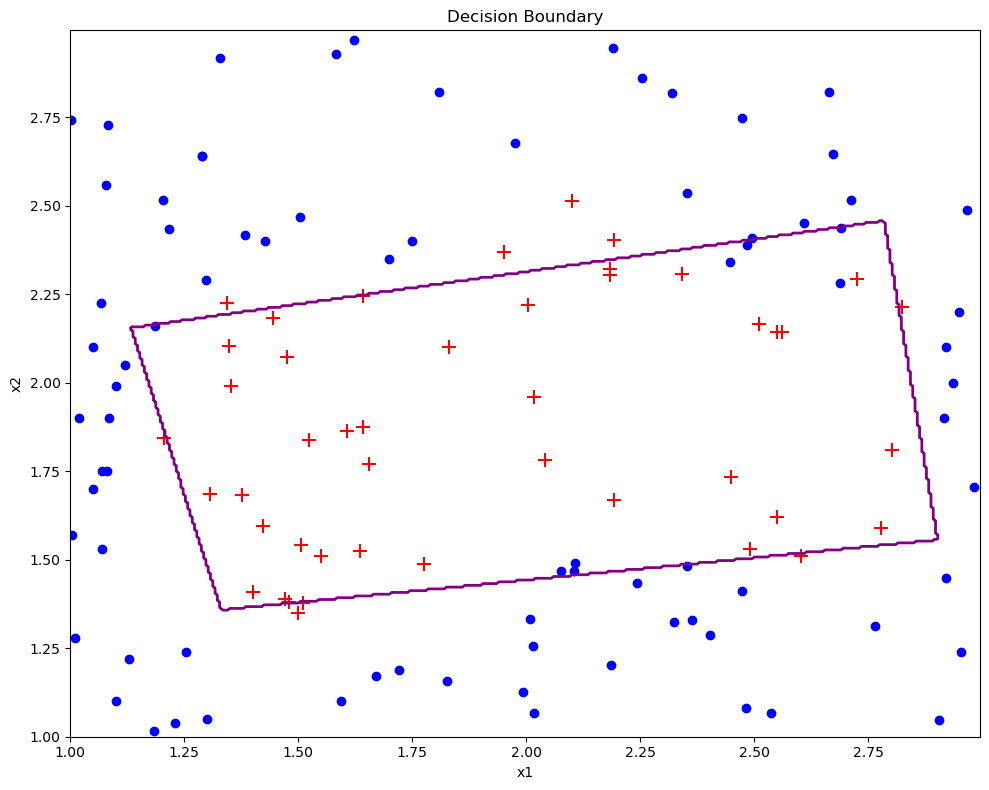


Model parameters:
model.0.weight: tensor([[-1.7508,  2.0661],
        [-0.9761, -2.5754],
        [-1.3415, -0.1562]])
model.0.bias: tensor([ 0.4777, -0.0903,  2.2510])
model.2.weight: tensor([[-2.6671, -2.6223,  2.5769]])
model.2.bias: tensor([-0.3782])


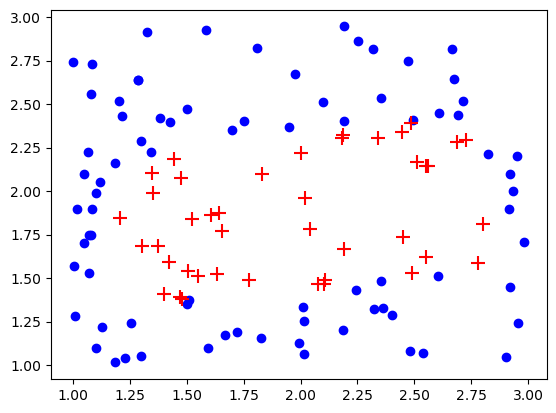

In [17]:
# Plot the loss curves
plot_losses(train_losses, test_losses)

# Evaluate the model
evaluate_model(model, X_train, y_train)
# Get predictions
if len(x_columns) == 2:
    plot_decision_boundary(model, X_train, y_train, scaler, feature_names=x_columns)

# Print model parameters
print("\nModel parameters:")
for name, param in model.named_parameters():
    print(f"{name}: {param.data}")
X_train, X_test, y_train, y_test, scaler = prepare_data(
    df, x_cols=x_columns, y_col=y_column, test_size=0.05
)
y_predt = model(X_train)

# Convert predictions to binary (0 or 1)
y_pred_binary = (y_predt > 0.5).float()
o = y_pred_binary == 0
plus = y_pred_binary == 1

original_data = scaler.inverse_transform(X_train.numpy())

#plt.scatter(original_data[:, 0], original_data[:, 1], c=y_pred_binary.squeeze(), edgecolors='k', cmap=plt.cm.RdBu)
plt.scatter(original_data[o.reshape(-1,), 0], original_data[o.reshape(-1,), 1], marker='o', color='blue', label='y=0')

# Plot points where y=1 as plus signs
plt.scatter(original_data[plus.reshape(-1,), 0], original_data[plus.reshape(-1,), 1], marker='+', color='red', s=100, label='y=1')

In [9]:
torch.save(model.state_dict(), 'nn4sided89.pth')

In [18]:
torch.save(model.state_dict(), 'nn4sided86_chosen.pth')

In [109]:
X = df[['x1','x2']].values
y = df['y'].values.reshape(-1, 1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.005, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)

Test Accuracy: 0.8333
Confusion Matrix:
True Positives: 36.0, False Positives: 11.0
True Negatives: 79.0, False Negatives: 12.0


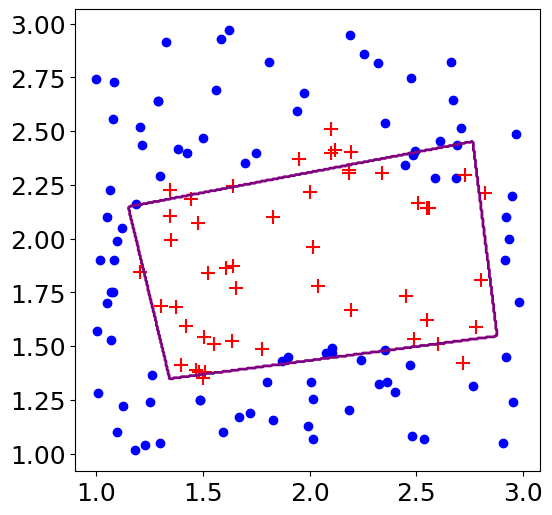


Model parameters:
model.0.weight: tensor([[-1.7508,  2.0661],
        [-0.9761, -2.5754],
        [-1.3415, -0.1562]])
model.0.bias: tensor([ 0.4777, -0.0903,  2.2510])
model.2.weight: tensor([[-2.6671, -2.6223,  2.5769]])
model.2.bias: tensor([-0.3782])


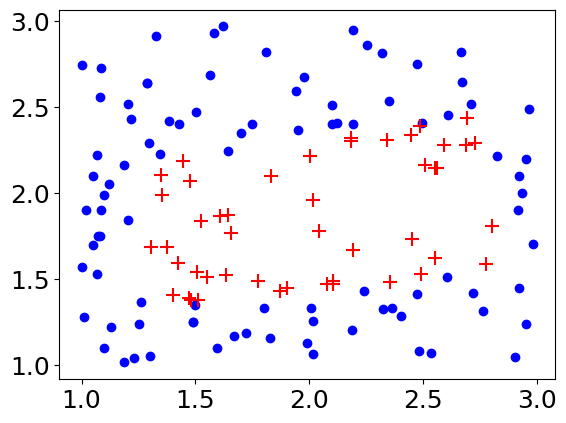

In [138]:
evaluate_model(model, X_train, y_train)
# Get predictions
if len(x_columns) == 2:
    plot_decision_boundary(model, X_train, y_train, scaler, feature_names=x_columns)

# Print model parameters
print("\nModel parameters:")
for name, param in model.named_parameters():
    print(f"{name}: {param.data}")

y_predt = model(X_train)

# Convert predictions to binary (0 or 1)
y_pred_binary = (y_predt > 0.5).float()
o = y_pred_binary == 0
plus = y_pred_binary == 1

original_data = scaler.inverse_transform(X_train.numpy())

#plt.scatter(original_data[:, 0], original_data[:, 1], c=y_pred_binary.squeeze(), edgecolors='k', cmap=plt.cm.RdBu)
plt.scatter(original_data[o.reshape(-1,), 0], original_data[o.reshape(-1,), 1], marker='o', color='blue', label='y=0')

# Plot points where y=1 as plus signs
plt.scatter(original_data[plus.reshape(-1,), 0], original_data[plus.reshape(-1,), 1], marker='+', color='red', s=100, label='y=1')

(array([19., 17., 18., 11.,  9., 16., 11., 14., 12., 11.]),
 array([-1.5111146 , -1.17815959, -0.84520465, -0.51224971, -0.17929474,
         0.15366024,  0.48661521,  0.81957018,  1.15252519,  1.48548007,
         1.81843507]),
 <BarContainer object of 10 artists>)

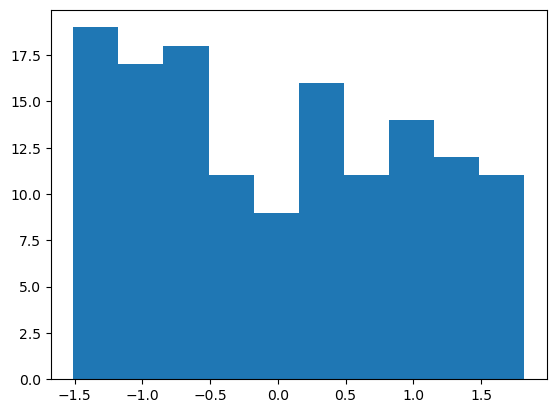

In [60]:
X = df[['x1','x2']].values
y = df['y'].values.reshape(-1, 1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.005, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_train = torch.FloatTensor(X_train)
plt.hist(X_train[:,0])

In [75]:
torch.min(X_train[:,1])

tensor(-1.6331)

In [76]:
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
result = 1.5 * x
print(result)

tensor([[1.5000, 3.0000],
        [4.5000, 6.0000]])


In [77]:
class InputTransform(nn.Module):
    def __init__(self, input_dim=2, neuron_n=16):
        super(InputTransform, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(input_dim, neuron_n),
            nn.LeakyReLU(0.1),
            nn.Linear(neuron_n, input_dim),
            nn.Tanh()
        )
    
    def forward(self, x):
        x = self.net(x)
        # x = 1.9 * x
        return x
    
class CombinedModel(nn.Module):
    def __init__(self, simple_model, transformer):
        super(CombinedModel, self).__init__()
        self.simple = simple_model
        self.transformer = transformer
        
        for param in self.simple.parameters():
            param.require_grad = False
    
    
    def forward(self, x):
        change = self.transformer(x)
        new_input = x + change
        output = self.simple(new_input)
        return {
            'change' : change,
            'output' : output
        }
        
        

In [80]:
input_transformer = InputTransform(input_dim=2).to(device)
combined_model = CombinedModel(simple_model=model, transformer=input_transformer).to(device)


In [83]:
optimizer = optim.Adam(combined_model.transformer.parameters(), lr=0.005)
classification_criterion = nn.BCELoss(reduction='sum')
mse_criterion = nn.MSELoss()
train_losses = []
print("Training the combined model")
num_epochs = 100
for epoch in range(num_epochs):
    combined_model.transformer.train()
    

    
    optimizer.zero_grad()
    
    outputs = combined_model(X_train)
    classifier_loss = classification_criterion(outputs['output'], y_train)
    loss = classifier_loss + torch.norm(outputs['change'], p=2)
    
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss)
    if (epoch+1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}=class: {classifier_loss} + norm: {torch.norm(outputs["change"], p=2)}')
            
            


Training the combined model
Epoch [10/100], Train Loss: 61.8796=class: 58.25145721435547 + norm: 3.628119707107544
Epoch [20/100], Train Loss: 53.3614=class: 51.03004455566406 + norm: 2.331355571746826
Epoch [30/100], Train Loss: 49.5958=class: 47.38853454589844 + norm: 2.2072863578796387
Epoch [40/100], Train Loss: 46.5288=class: 44.385135650634766 + norm: 2.1437036991119385
Epoch [50/100], Train Loss: 43.7224=class: 41.691158294677734 + norm: 2.03127384185791
Epoch [60/100], Train Loss: 41.4032=class: 39.25046157836914 + norm: 2.152747392654419
Epoch [70/100], Train Loss: 39.4060=class: 37.230499267578125 + norm: 2.1754586696624756
Epoch [80/100], Train Loss: 37.5594=class: 35.25111389160156 + norm: 2.3083221912384033
Epoch [90/100], Train Loss: 36.1613=class: 33.61811065673828 + norm: 2.543151617050171
Epoch [100/100], Train Loss: 34.9193=class: 32.130855560302734 + norm: 2.7884581089019775
Test Accuracy: 0.9565
Confusion Matrix:
True Positives: 43.0, False Positives: 1.0
True Negat

Test Accuracy: 0.9565
Confusion Matrix:
True Positives: 43.0, False Positives: 1.0
True Negatives: 89.0, False Negatives: 5.0


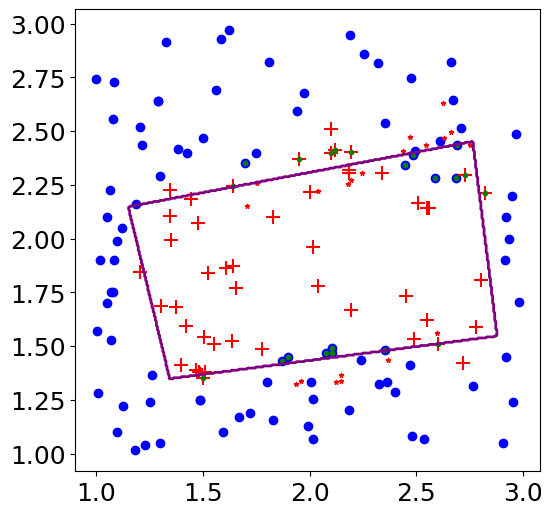

In [136]:
with torch.no_grad():

        y_pred = combined_model(X_train)
        y_pred_original = model(X_train)
        y_pred_original = (y_pred_original > 0.5).float()
        y_pred_binary = (y_pred['output'] > 0.5).float()
        points_changed = (y_pred_original != y_pred_binary)

        X_changed = X_train[points_changed.reshape(-1,),:]
        change_ = y_pred['change'][points_changed.reshape(-1,),:]
        new_x = X_changed + change_
        original_data = scaler.inverse_transform(X_train.numpy())
        X_changed_scaled = scaler.inverse_transform(X_changed.numpy())
        new_x = scaler.inverse_transform(new_x.numpy())
        
        
        o = y_train == 0
        plus = y_train == 1
        
        
        # plot_decision_boundary(model, X_train, y_train, scaler, feature_names=x_columns)
        
        x1_min, x1_max = 1.0, 3
        x2_min, x2_max = 1, 3
        h = 0.005
        xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, h), np.arange(x2_min, x2_max, h))
        
        # Scale mesh grid points
        grid_points = np.c_[xx1.ravel(), xx2.ravel()]
        scaled_grid_points = scaler.transform(grid_points)
        
        # Predict for each point in the mesh grid
        Z = model(torch.FloatTensor(scaled_grid_points))
        Z = Z.detach().numpy().reshape(xx1.shape)
        Z = (Z > 0.5).astype(int)
        # Plot decision boundary and data points
        
        plt.rcParams.update({'font.size': 18})
        plt.figure(figsize=(6, 6))
        # This functions colors the inside of the plot
        # plt.contourf(xx1, xx2, Z, alpha=0.8, cmap=plt.cm.Purples)
        plt.contour(xx1, xx2, Z, levels=[0.5], colors='purple', linewidths=2)
        #plt.scatter(original_data[:, 0], original_data[:, 1], c=y_pred_binary.squeeze(), edgecolors='k', cmap=plt.cm.RdBu)
        # plt.figure(figsize=((6,6)))
        plt.ylim(0.9174749336465787, 3.066280477258978)
        plt.xlim(0.9029601334007787, 3.081167360786655)
        plt.scatter(original_data[o.reshape(-1,), 0], original_data[o.reshape(-1,), 1], marker='o', color='blue', label='y=0')

        # Plot points where y=1 as plus signs
        plt.scatter(original_data[plus.reshape(-1,), 0], original_data[plus.reshape(-1,), 1], marker='+', color='red', s=100, label='y=1')
        #plt.scatter(original_data[:, 0], original_data[:, 1], c=y_pred_binary.squeeze(), edgecolors='k', cmap=plt.cm.RdBu)
        plt.scatter(X_changed_scaled[:, 0], X_changed_scaled[:, 1], marker='.', color='green', label='original to be changed')

        # Plot points where y=1 as plus signs
        plt.scatter(new_x[:, 0], new_x[:, 1], marker='*', color='red', s=10, label='changed data')
        # plt.legend()
        plt.savefig("combined.pdf", format='pdf')
        accuracy = (y_pred_binary == y_train).float().mean().item()
        
        print(f'Test Accuracy: {accuracy:.4f}')

        true_positives = ((y_pred_binary == 1) & (y_train == 1)).float().sum().item()
        false_positives = ((y_pred_binary == 1) & (y_train == 0)).float().sum().item()
        true_negatives = ((y_pred_binary == 0) & (y_train == 0)).float().sum().item()
        false_negatives = ((y_pred_binary == 0) & (y_train == 1)).float().sum().item()
        
        print("Confusion Matrix:")
        print(f"True Positives: {true_positives}, False Positives: {false_positives}")
        print(f"True Negatives: {true_negatives}, False Negatives: {false_negatives}")

In [133]:
torch.save(combined_model.state_dict(), 'binarycombined.pth')